# City Life Clustering Analysis

## Importing Necessary Packages

In [1]:
# Importing Data Manipulation
import pandas as pd
import numpy as np

# Importing Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet
from sklearn.decomposition import PCA

## Importing Necessary Packages

In [2]:
df = pd.read_csv("city_lifestyle_dataset.csv")
df.head()

,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,Old Vista,Europe,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,Beachport,Europe,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,Valleyborough,Europe,2562,4310,80.1,1330,39,73.2,8.5,40.2
3,City,Europe,3192,3970,81.2,1480,60,49.2,8.5,43.6
4,Falls,Europe,3496,4320,100.0,1510,64,93.7,8.5,42.5


## Data Overview

In [3]:
# Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city_name               300 non-null    object 
 1   country                 300 non-null    object 
 2   population_density      300 non-null    int64  
 3   avg_income              300 non-null    int64  
 4   internet_penetration    300 non-null    float64
 5   avg_rent                300 non-null    int64  
 6   air_quality_index       300 non-null    int64  
 7   public_transport_score  300 non-null    float64
 8   happiness_score         300 non-null    float64
 9   green_space_ratio       300 non-null    float64
dtypes: float64(4), int64(4), object(2)
memory usage: 23.6+ KB


In [4]:
# Summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
population_density,300.0,3944.843333,2982.566777,100.0,1830.000,3083.5,4823.750,14427.0
avg_income,300.0,2827.200000,1201.163939,480.0,1907.500,2810.0,3752.500,5720.0
internet_penetration,300.0,74.305333,17.014492,34.0,64.400,75.0,87.225,100.0
avg_rent,300.0,1002.766667,456.282066,170.0,640.000,990.0,1332.500,2430.0
air_quality_index,300.0,71.246667,25.344961,22.0,54.000,67.5,86.000,146.0
public_transport_score,300.0,55.717333,14.712549,15.0,46.075,54.7,64.200,95.0
happiness_score,300.0,6.644000,1.685864,2.5,5.300,6.9,8.500,8.5
green_space_ratio,300.0,33.993333,9.434067,2.0,28.225,34.7,40.400,58.0


In [5]:
# Value Counts
cat = ['city_name', 'country']

for i in cat:
    
    print(f"\nPercentage Distribution for {i}")
    
    print((df[i].value_counts(normalize=True) * 100).round(2))
    
    print('*' * 50)


Percentage Distribution for city_name
city_name
Old Vista      0.33
West Garden    0.33
Vistaburg      0.33
North Park     0.33
Wooddale       0.33
               ... 
Port Falls     0.33
Parkhaven      0.33
Pointford      0.33
Parkshire      0.33
Townshire      0.33
Name: proportion, Length: 300, dtype: float64
**************************************************

Percentage Distribution for country
country
Asia             26.67
Europe           20.00
North America    16.67
South America    13.33
Africa           11.67
Oceania          11.67
Name: proportion, dtype: float64
**************************************************


## EDA

In [6]:
# Making a copy
data = df.copy()

### Univariate Analysis

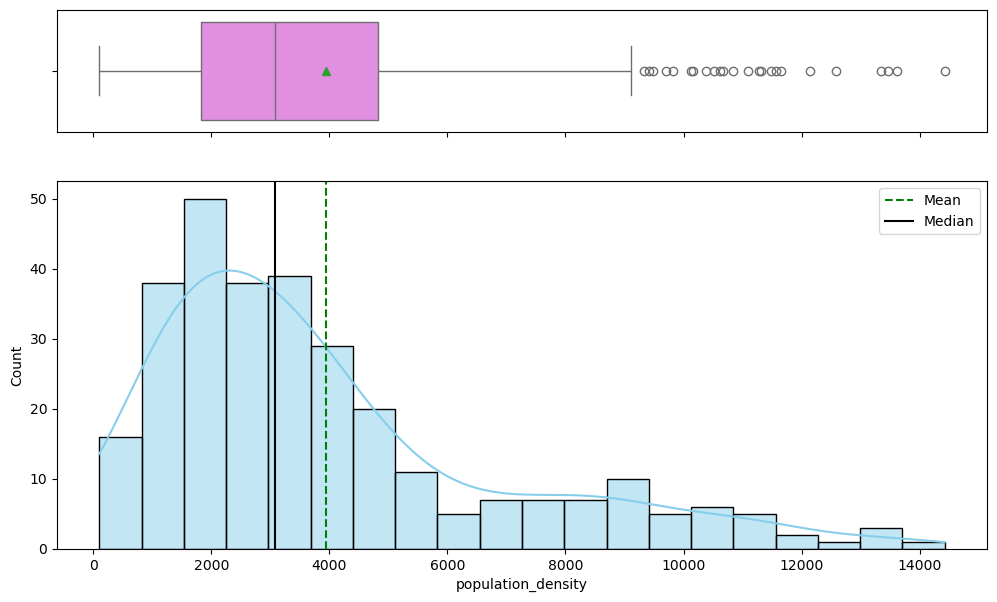

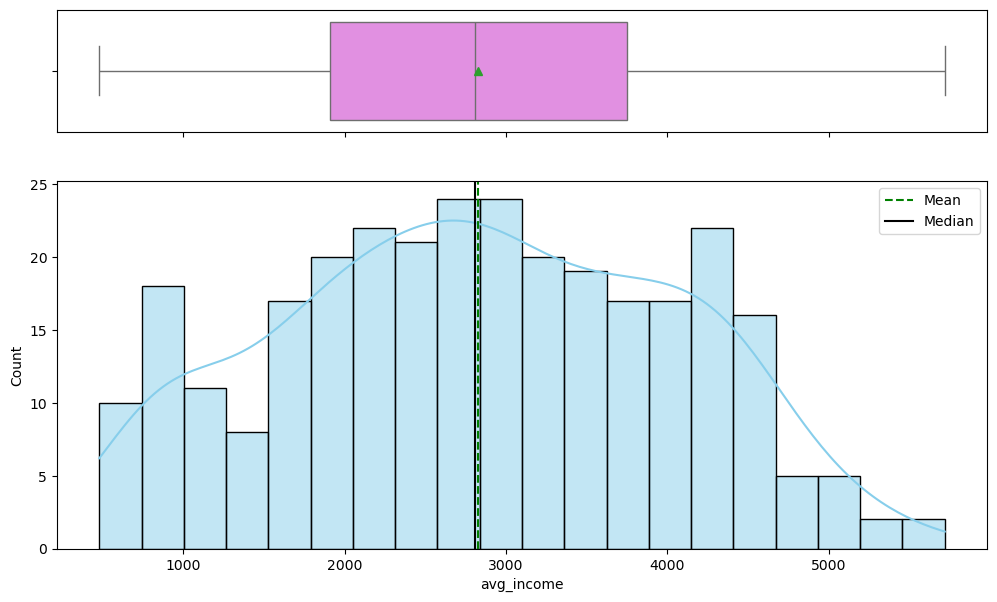

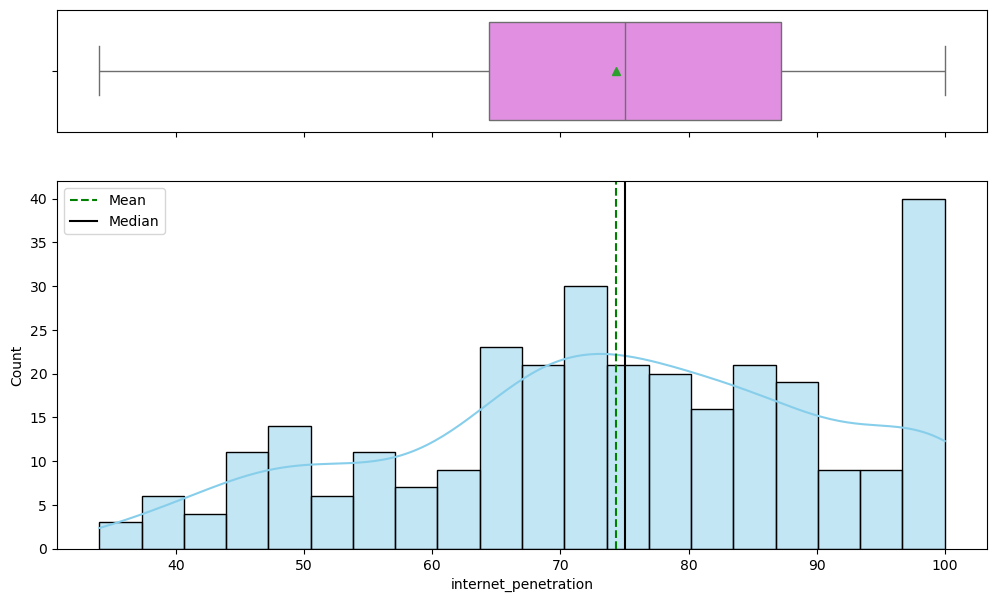

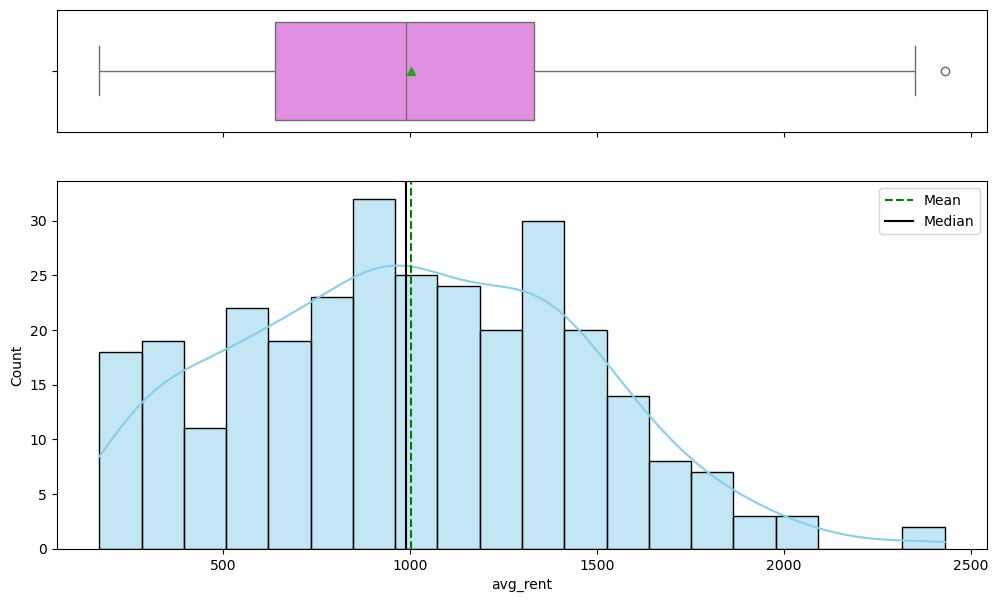

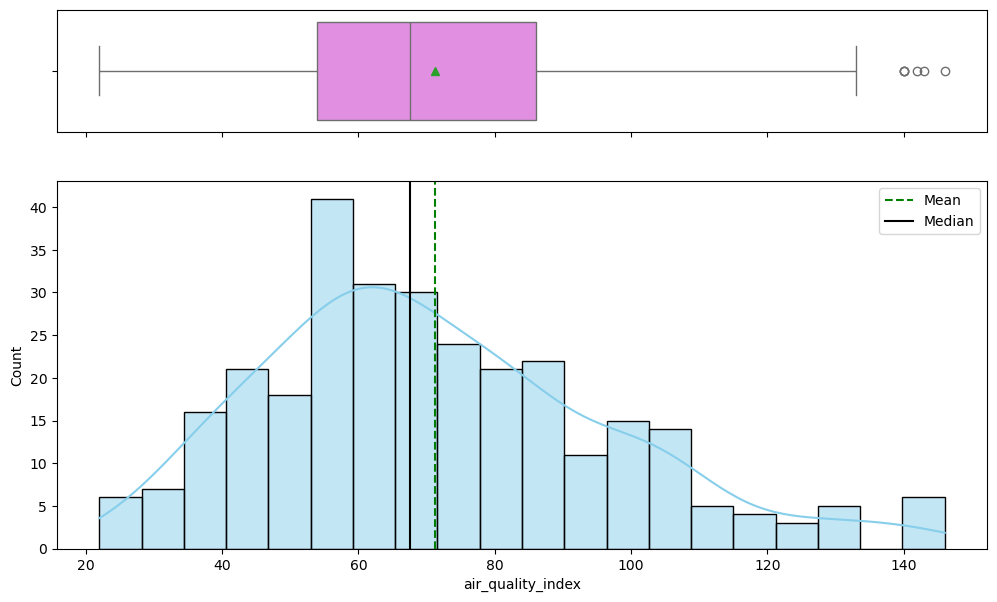

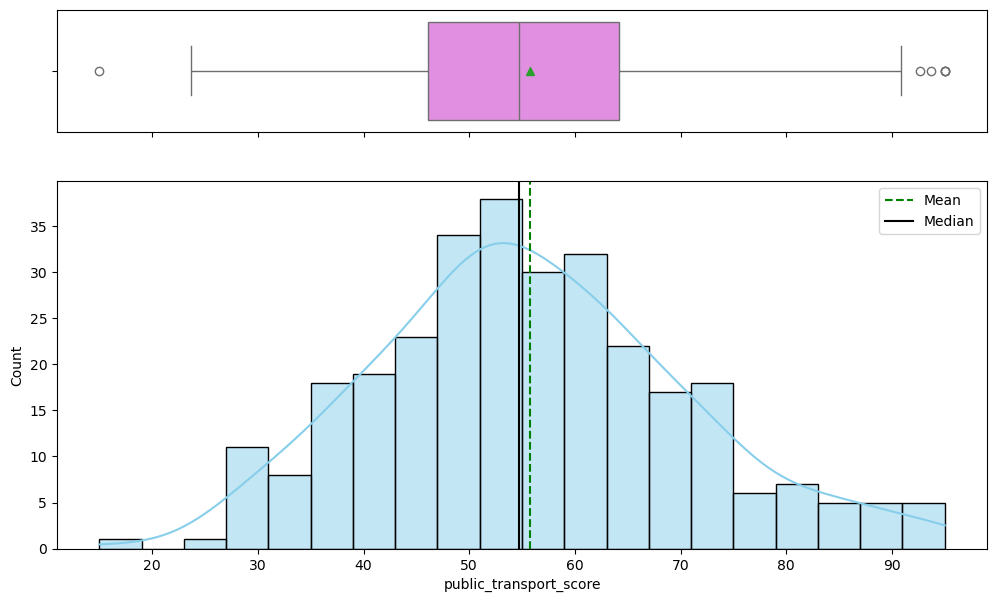

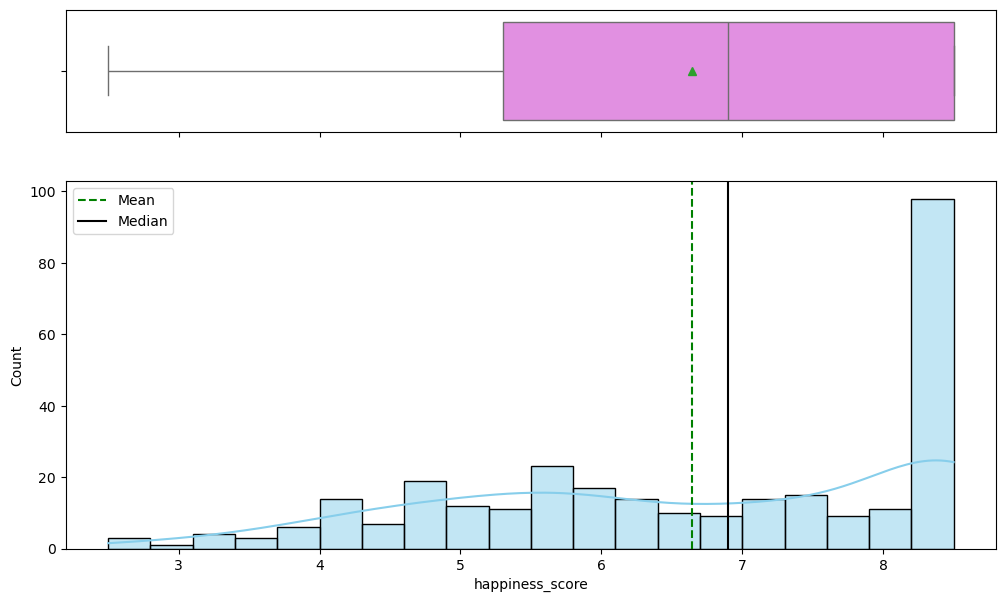

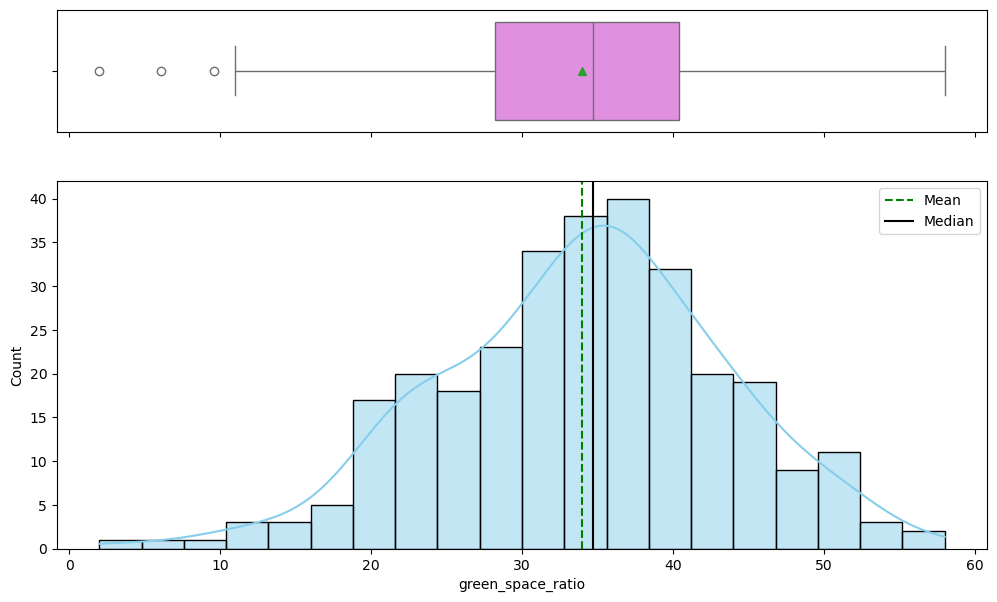

In [7]:
numerical = data.select_dtypes(include=np.number).columns.tolist()

def histogram_boxplot(df, feature, figsize=(12,7), kde=False, bins=None):
    
    # Create subplots
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize
    )

    # Boxplot
    sns.boxplot(
        data=df,
        x=feature,
        ax=ax_box2,
        showmeans=True,
        color='violet'
    )

    # Histogram
    if bins:
        sns.histplot(
            data=df,
            x=feature,
            kde=kde,
            bins=bins,
            ax=ax_hist2,
            color='skyblue'
        )
    else:
        sns.histplot(
            data=df,
            x=feature,
            kde=kde,
            ax=ax_hist2,
            color='skyblue'
        )

    # Mean line
    ax_hist2.axvline(
        df[feature].mean(),
        color='green',
        linestyle='--',
        label='Mean'
    )

    # Median line
    ax_hist2.axvline(
        df[feature].median(),
        color='black',
        linestyle='-',
        label='Median'
    )

    # Legend
    ax_hist2.legend()

    plt.show()


for i in numerical:
    
    histogram_boxplot(
        df,
        feature=i,
        kde=True,
        bins=20
    )

### Bivariate Analysis

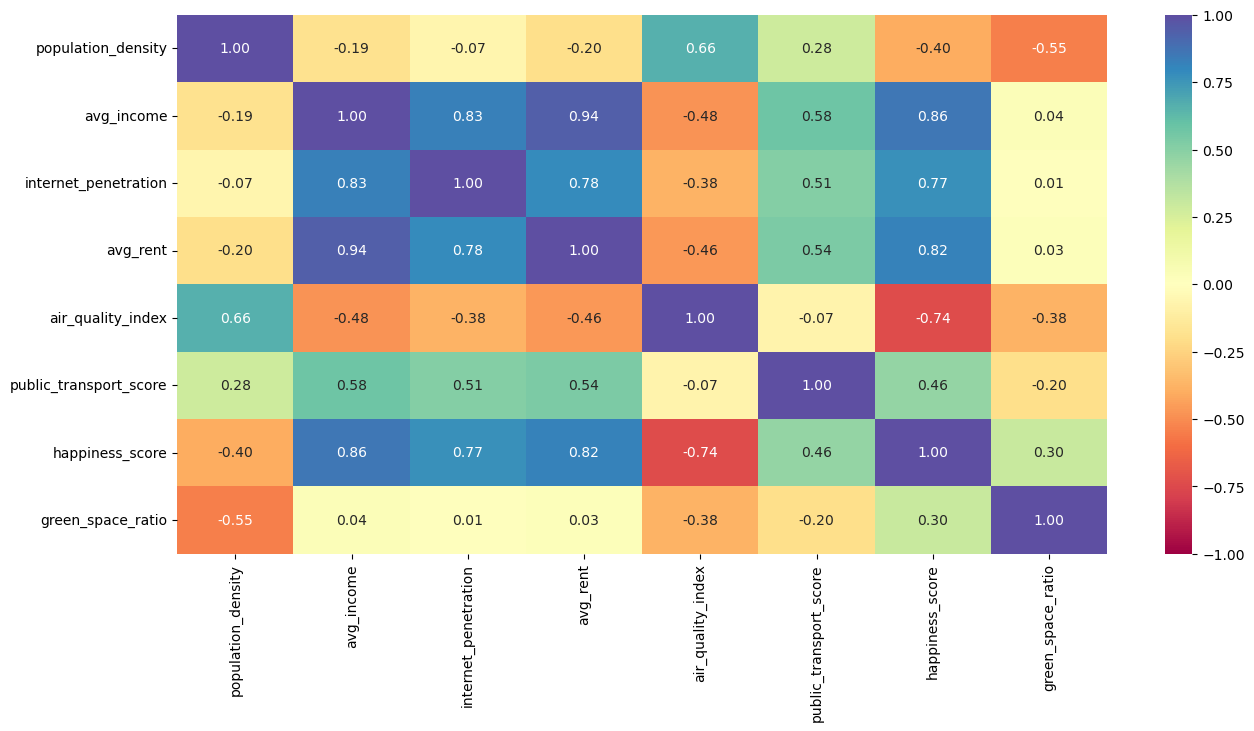

In [8]:
# Heatmap
plt.figure(figsize=(15,7))
sns.heatmap(data[numerical].corr(), annot=True, fmt='.2f', vmin=-1, vmax=1, cmap='Spectral')
plt.show()

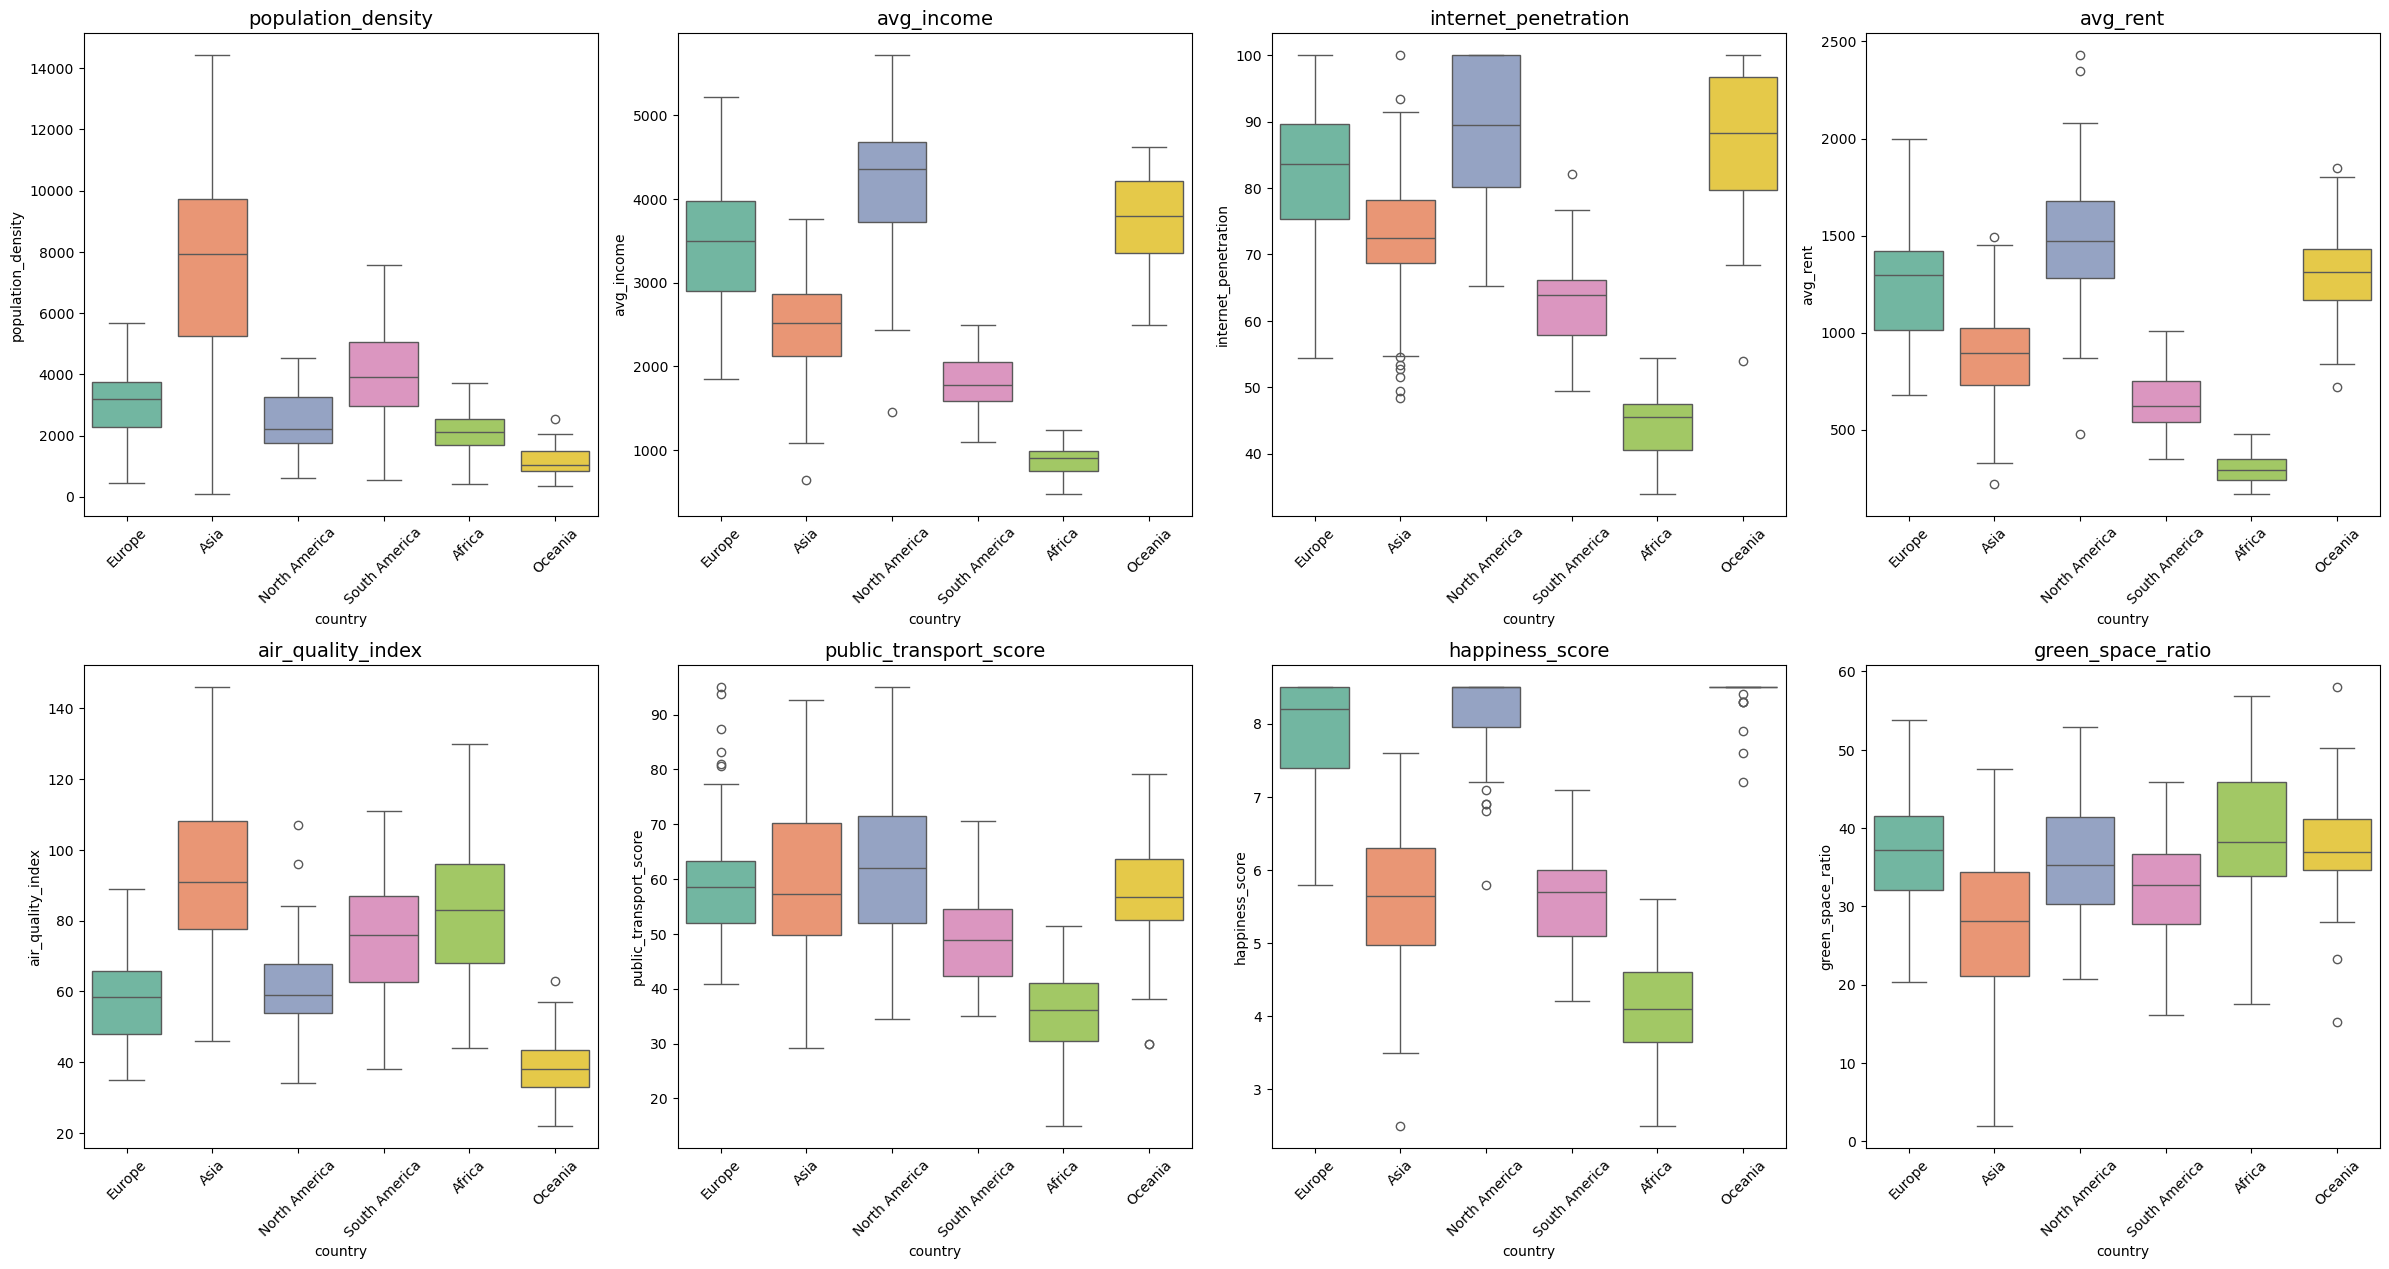

In [9]:
# Boxplots by Country
plt.figure(figsize=(24,18))  # Bigger overall figure size
for i, variable in enumerate(numerical):
    plt.subplot(3, 4, i + 1)
    sns.boxplot(
        data=df,
        x='country',
        y=variable,
        hue='country',
        palette='Set2',
        legend=False
    )

    plt.title(variable, fontsize=14)
    plt.xticks(rotation=45, fontsize=10)
    plt.yticks(fontsize=10)

plt.tight_layout()

plt.show()

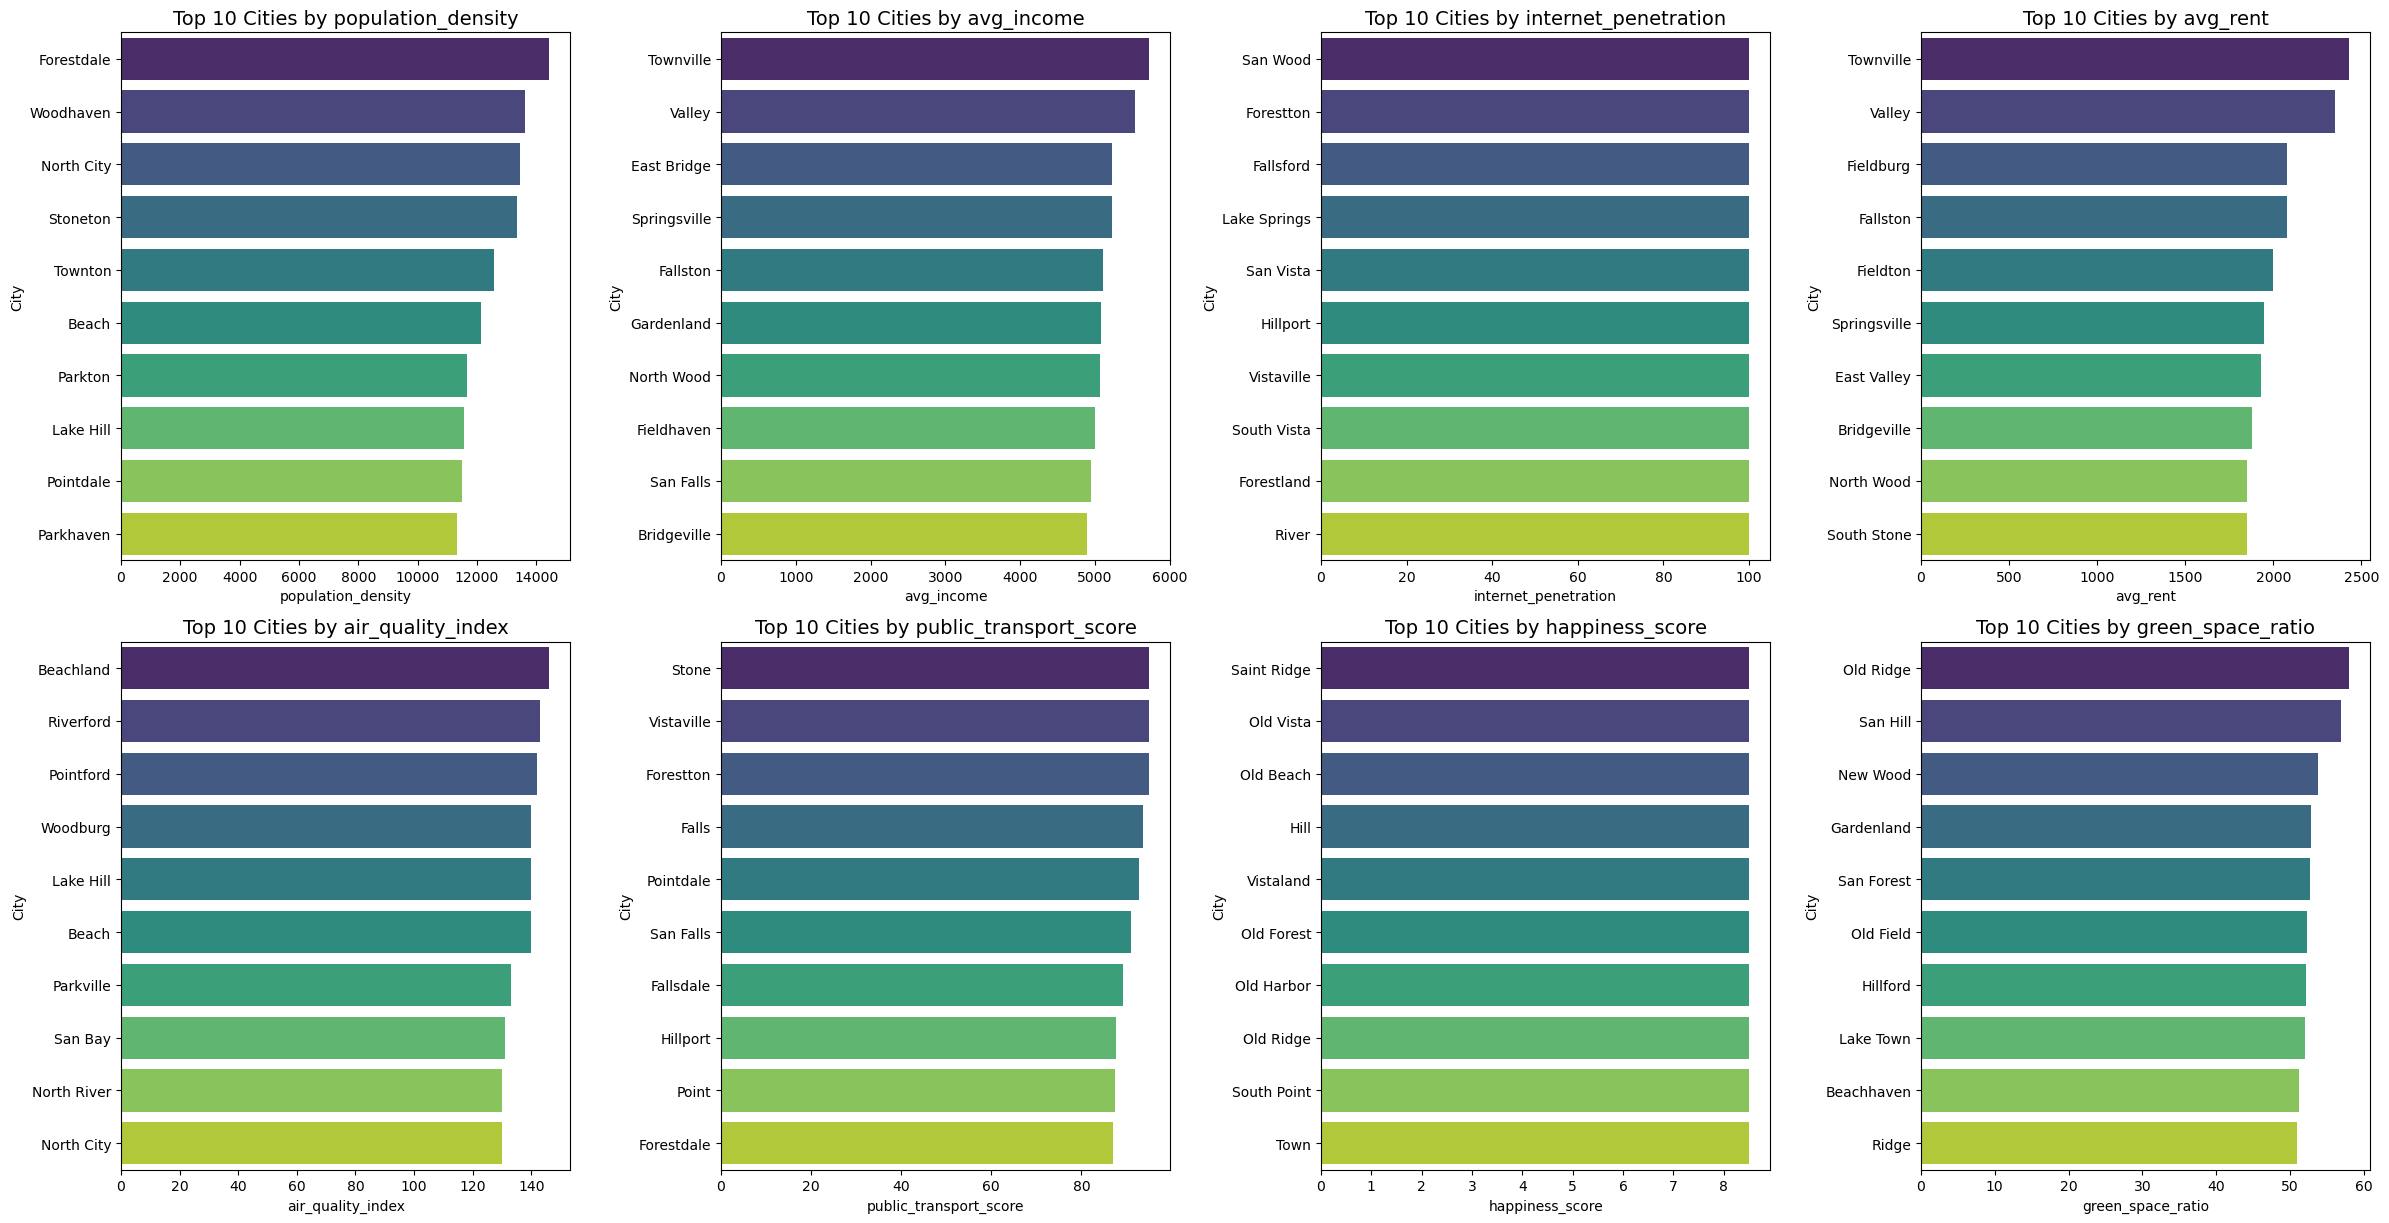

In [10]:
# TOP 10 CITIES BY NUMERICAL VARIABLES
# BAR CHARTS

plt.figure(figsize=(24,18))
for i, variable in enumerate(numerical):
    # Top 10 cities based on average value
    top_10 = (
        df.groupby('city_name')[variable]
        .mean()
        .sort_values(ascending=False)
        .head(10)
        .reset_index()
    )
    # Subplot
    plt.subplot(3, 4, i + 1)
    sns.barplot(
        data=top_10,
        x=variable,
        y='city_name',
        hue='city_name',
        palette='viridis',
        legend=False
    )
    plt.title(f"Top 10 Cities by {variable}", fontsize=14)
    plt.xlabel(variable)
    plt.ylabel("City")
plt.tight_layout()
plt.show()

## Clustering Analysis

### Data Preprocessing

In [11]:
# Data Preprocessing
X = data[numerical]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled

array([[-3.92882389e-01,  8.52930151e-01,  7.12032705e-01, ...,
        -2.53086289e-01,  1.10275857e+00, -1.08228661e+00],
       [-2.81581030e-02,  7.27842624e-01,  2.23398201e-01, ...,
         4.82207450e-01,  8.65095083e-01, -9.48504942e-02],
       [-4.64416710e-01,  1.23653190e+00,  3.41141455e-01, ...,
         1.19026809e+00,  1.10275857e+00,  6.58998583e-01],
       ...,
       [-1.04407980e+00,  9.02965162e-01,  1.43615372e+00, ...,
        -1.18010106e-03,  1.10275857e+00,  4.89117101e-01],
       [-1.07027547e+00,  5.52720086e-01,  9.94616515e-01, ...,
        -1.10112507e-01,  1.10275857e+00,  1.12617266e+00],
       [-9.10078890e-01,  1.25321024e+00,  7.12032705e-01, ...,
         1.33324187e+00,  1.10275857e+00,  6.27145805e-01]],
      shape=(300, 8))

### Cluster Analysis

In [12]:
# Elbow Method and Silhouette Scores

inertia = []
silhouette_scores = []

k_values = range(2, 14)

# Calculate metrics for each K

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Fit and predict
    labels = kmeans.fit_predict(X_scaled)

    # Inertia
    inertia.append(kmeans.inertia_)

    # Silhouette Score
    score = silhouette_score(X_scaled, labels)

    silhouette_scores.append(score)

    # Print results
    print(f"K = {k} | Inertia = {kmeans.inertia_:.2f} | Silhouette Score = {score:.4f}")

C:\Users\muzam\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\muzam\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\muzam\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\muzam\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

K = 2 | Inertia = 1411.05 | Silhouette Score = 0.3555
K = 3 | Inertia = 1036.59 | Silhouette Score = 0.3562
K = 4 | Inertia = 890.43 | Silhouette Score = 0.2702
K = 5 | Inertia = 811.70 | Silhouette Score = 0.2297
K = 6 | Inertia = 749.93 | Silhouette Score = 0.2034
K = 7 | Inertia = 698.87 | Silhouette Score = 0.1820
K = 8 | Inertia = 653.87 | Silhouette Score = 0.1974


C:\Users\muzam\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\muzam\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\muzam\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\muzam\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

K = 9 | Inertia = 620.42 | Silhouette Score = 0.1948
K = 10 | Inertia = 593.56 | Silhouette Score = 0.1863
K = 11 | Inertia = 572.56 | Silhouette Score = 0.1823


C:\Users\muzam\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\muzam\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\muzam\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


K = 12 | Inertia = 553.72 | Silhouette Score = 0.1698
K = 13 | Inertia = 535.87 | Silhouette Score = 0.1767


C:\Users\muzam\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


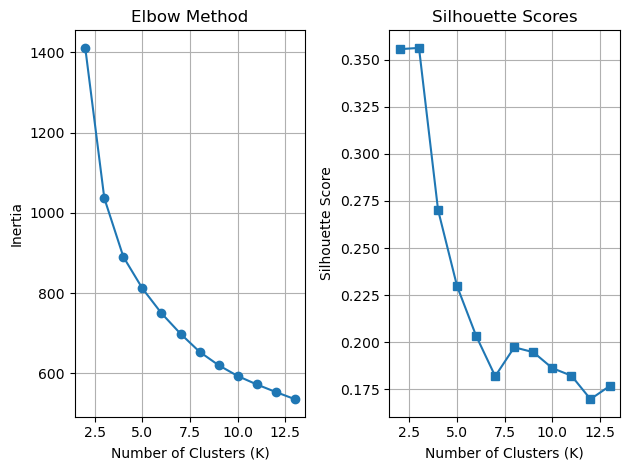

In [13]:
# ==========================================
# Elbow Method
# ==========================================

plt.subplot(1, 2, 1)

plt.plot(
    k_values,
    inertia,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.grid(True)

# ==========================================
# Silhouette Scores
# ==========================================

plt.subplot(1, 2, 2)

plt.plot(
    k_values,
    silhouette_scores,
    marker='s'
)

plt.xlabel("Number of Clusters (K)")

plt.ylabel("Silhouette Score")

plt.title("Silhouette Scores")

plt.grid(True)

# ==========================================

plt.tight_layout()

plt.show()

### Model K-Means

In [14]:
# Create scaled dataframe
subset_scaled_df = pd.DataFrame(
    X_scaled,
    columns=data[numerical].columns
)

# KMeans model
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Fit on scaled numerical data
kmeans.fit(subset_scaled_df)

# Copy original data
df1 = data.copy()

# Add cluster labels
df1['KM_Segments'] = kmeans.labels_

# View results
df1.head()

C:\Users\muzam\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio,KM_Segments
0,Old Vista,Europe,2775,3850,86.4,1310,43,52.0,8.5,23.8,1
1,Beachport,Europe,3861,3700,78.1,1330,42,62.8,8.1,33.1,1
2,Valleyborough,Europe,2562,4310,80.1,1330,39,73.2,8.5,40.2,1
3,City,Europe,3192,3970,81.2,1480,60,49.2,8.5,43.6,1
4,Falls,Europe,3496,4320,100.0,1510,64,93.7,8.5,42.5,1


In [15]:
# Cluster Profile

km_cluster_profile = (
    df1.groupby('KM_Segments')[numerical]
    .mean()
)

# Count in each cluster
km_cluster_profile['count in each segment'] = (
    df1.groupby('KM_Segments')['city_name']
    .count()
    .values
)

# Highlight maximum values
km_cluster_profile.style.highlight_max(
    color='lightgreen',
    axis=0
)

,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio,count in each segment
KM_Segments,,,,,,,,,
0,2991.329412,1434.000000,55.301176,495.411765,78.517647,40.991765,4.965882,36.027059,85
1,2367.335664,3804.055944,86.260140,1361.538462,53.762238,60.756643,8.153846,37.082517,143
2,8203.625000,2531.805556,72.997222,889.166667,97.388889,63.093056,5.626389,25.456944,72


### PCA Analysis

In [16]:
#Setting the number of components to 2
km_pca = PCA(n_components=2)

#Transforming the data and storing the results in a dataframe
km_reduced_pca = km_pca.fit_transform(subset_scaled_df)
km_redcued_pca_df = pd.DataFrame(data=km_reduced_pca, columns=['Component 1','Component 2'])

In [17]:
print(km_pca.explained_variance_ratio_.sum())
print(np.cumsum(km_pca.explained_variance_ratio_))

0.79638920001258
[0.53805804 0.7963892 ]


<Axes: xlabel='Component 1', ylabel='Component 2'>

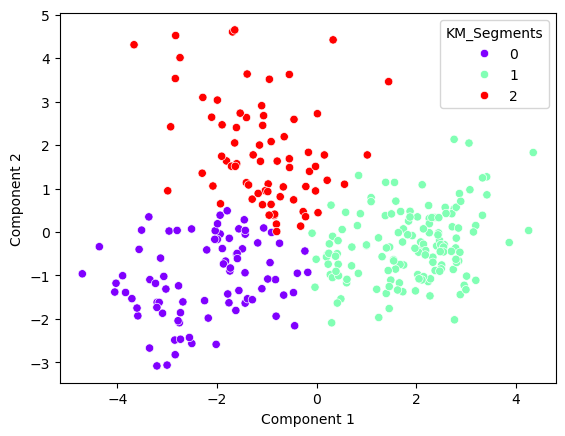

In [18]:
#Scatterplot
sns.scatterplot(data=km_redcued_pca_df, x='Component 1', y='Component 2', hue=df1['KM_Segments'], palette='rainbow')

In [19]:
for cluster in sorted(df1['KM_Segments'].unique()):

    cities = df1[df1['KM_Segments'] == cluster]['city_name'].tolist()

    print(f"\nCluster {cluster}")
    print("-" * 40)

    for city in cities:
        print(city)


Cluster 0
----------------------------------------
Bridge
Harborshire
Harborport
Gardenborough
Old Wood
Old Springs
Park
Hilldale
Bridgeburg
Mount Falls
West Bay
Bayshire
Saint Field
Stonedale
Pointport
East City
Lake Wood
Forestport
Saint Point
Woodville
West Ridge
Lake Garden
Vistadale
North Valley
East Park
Gardenville
Port Garden
Citydale
Wooddale
North Park
Vistaburg
Riverport
West Garden
Stoneford
Fieldland
Mount Point
Cityton
Mount Springs
Hillshire
Ridgeborough
Harborton
Valleyland
Gardendale
Saint Town
Springshaven
San Ridge
Old Valley
Mount River
New Town
Mount Town
Port Town
Valleyville
Old Bay
Springsburg
Beachhaven
West Harbor
Springsshire
North Springs
New Vista
Stoneborough
North River
Bayville
West City
East Wood
Parkburg
Old Field
Hillford
Valleyhaven
Fielddale
Riverdale
New Valley
San Hill
San Springs
Hillborough
Ridgeport
South Bridge
New Beach
Pointville
New Bay
North Bridge
Old Town
San Forest
Parkdale
New Ridge
South River

Cluster 1
-----------------------------